# MMIP: HW4
315831012 陳芊綺

## Quiz 1: 準備資料集

1. Sentiment Analysis資料集：IMDB 影評  
    - 共50000筆帶有英文影評的資料集，每筆影評分為正面/負面 
2. Image Classification資料集：CIFAR-10 
    - 共60000張彩色影像，分為50000張訓練集與10000張測試集，共有十分類別：飛機、汽車、鳥、貓、鹿、狗、青蛙、馬、船、卡車
3. Image Captioning資料集：Flickr8k
    - 包含8091張來自攝影平台 Flickr 的真實生活照片，每張圖提供5句描述是為了反映人類對同一張圖片的不同觀察角度與詞彙偏好

## Quiz 2: Sentiment Analysis

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tqdm.notebook import tqdm
from src.data_loader import ROOT, load_text_data, set_seed
from src.eval_metrics import (
    classification_metrics,
    compare_models,
    plot_confusion_matrix,
    plot_history,
    plot_metric_bars,
    print_report,
)
from src.models import LSTMClassifier, RNNClassifier
from src.train import count_parameters, get_device, measure_inference_time, predict, train_classifier

RESULT = ROOT / "result" / "quiz2"
RESULT.mkdir(parents=True, exist_ok=True)
device = get_device()
print("device:", device)

CFG = dict( # 參數在這調
    batch_size=64, max_len=256, max_vocab=20000,   # 資料
    embed_dim=128, hidden_dim=128, dropout=0.3,    # 模型
    lr=1e-3, epochs=15, clip=1.0,                   # 訓練
)
CLASS_NAMES = ["negative", "positive"]

train_loader, val_loader, test_loader, vocab = load_text_data(CFG["batch_size"], CFG["max_len"], CFG["max_vocab"])
test_df = pd.read_csv(ROOT / "dataset" / "quiz2" / "test.csv")  # test_loader 不洗牌，順序與此 CSV 一致
print("vocab size:", len(vocab), "| test samples:", len(test_df))

device: cuda
vocab size: 20000 | test samples: 4959


扣除重複的資料集後，資料集為49582筆  
- 訓練集：39664筆
- 驗證集：4959筆
- 資料集：4959筆

### 建立並訓練RNN

RNNClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
trainable params: 2,593,282


[RNN] epoch 01/15 | train loss 0.6733 acc 0.5851 | val loss 0.6379 acc 0.6346 | 23.2s


[RNN] epoch 02/15 | train loss 0.6229 acc 0.6626 | val loss 0.6199 acc 0.6858 | 23.4s


[RNN] epoch 03/15 | train loss 0.5811 acc 0.7077 | val loss 0.6359 acc 0.6441 | 22.2s


[RNN] epoch 04/15 | train loss 0.5330 acc 0.7458 | val loss 0.6468 acc 0.7145 | 21.7s


...

[RNN] epoch 11/15 | train loss 0.3895 acc 0.8381 | val loss 0.4389 acc 0.8312 | 12.1s


[RNN] epoch 12/15 | train loss 0.3827 acc 0.8423 | val loss 0.4356 acc 0.8312 | 21.8s


[RNN] epoch 13/15 | train loss 0.3673 acc 0.8491 | val loss 0.4169 acc 0.8280 | 21.6s


[RNN] epoch 14/15 | train loss 0.3581 acc 0.8535 | val loss 0.4260 acc 0.8223 | 21.7s


[RNN] epoch 15/15 | train loss 0.3552 acc 0.8523 | val loss 0.4806 acc 0.8294 | 21.9s
best epoch 11 | val acc 0.8312 | total 321s


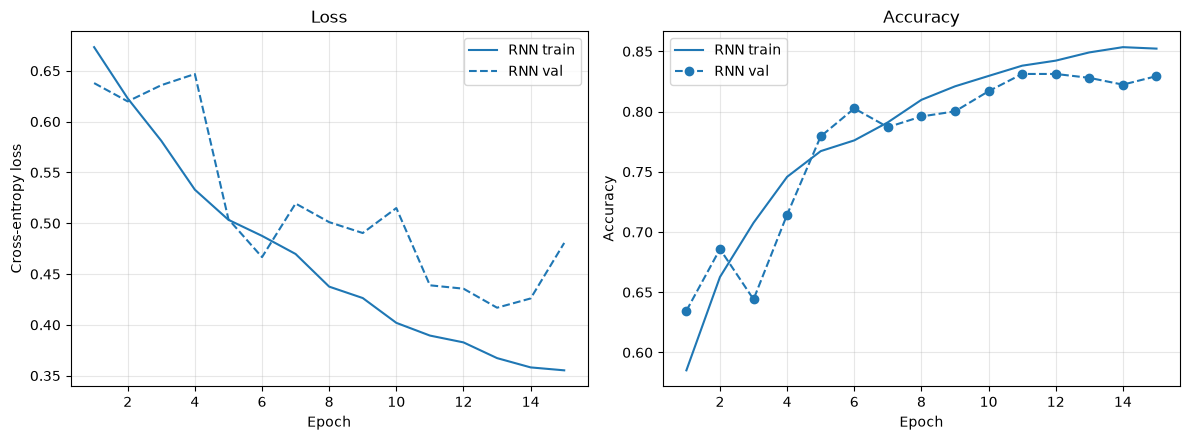

In [2]:
def build_model(cls):
    set_seed(42)  # 兩個模型從相同種子開始，初始化條件一致
    return cls(len(vocab), embed_dim=CFG["embed_dim"], hidden_dim=CFG["hidden_dim"], dropout=CFG["dropout"])


rnn = build_model(RNNClassifier)
print(rnn)
print("trainable params:", f"{count_parameters(rnn):,}")

set_seed(42)
rnn_hist = train_classifier(
    rnn, train_loader, val_loader, device,
    epochs=CFG["epochs"], lr=CFG["lr"], clip=CFG["clip"],
    ckpt_path=RESULT / "rnn_best.pt", name="RNN",
)
print(f"best epoch {rnn_hist['best_epoch']} | val acc {rnn_hist['best_val_acc']:.4f} | total {rnn_hist['total_time']:.0f}s")
plot_history({"RNN": rnn_hist}, RESULT / "rnn_curves.png")

### 使用測試集推論並呈現分類結果

== RNN 測試集結果 ==
{'Accuracy': 0.8294, 'Precision': 0.8305, 'Recall': 0.8293, 'F1': 0.8292, 'AUC': 0.9}
              precision    recall  f1-score   support

    negative     0.8482    0.8008    0.8238      2470
    positive     0.8127    0.8578    0.8346      2489

    accuracy                         0.8294      4959
   macro avg     0.8305    0.8293    0.8292      4959
weighted avg     0.8304    0.8294    0.8293      4959



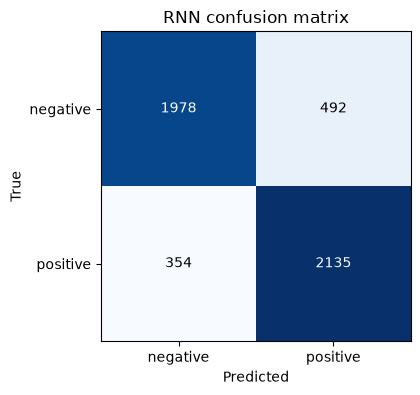

In [3]:
def evaluate_model(name, model):
    """對測試集推論，顯示並儲存分類結果，回傳指標。"""
    y_true, y_pred, probs = predict(model, test_loader, device)
    metrics = classification_metrics(y_true, y_pred, probs)
    print(f"== {name} 測試集結果 ==")
    print({k: round(v, 4) for k, v in metrics.items()})
    print_report(y_true, y_pred, CLASS_NAMES)
    plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, f"{name} confusion matrix", RESULT / f"{name.lower()}_confusion.png")

    idx = np.random.RandomState(0).choice(len(test_df), 10, replace=False)
    sample = pd.DataFrame({
        "review": test_df.text.iloc[idx].str.replace(r"<br\s*/?>", " ", regex=True).str[:90] + "...",
        "true": [CLASS_NAMES[i] for i in y_true[idx]],
        "pred": [CLASS_NAMES[i] for i in y_pred[idx]],
        "confidence": probs[idx].max(1).round(3),
        "correct": y_true[idx] == y_pred[idx],
    })
    sample.to_csv(RESULT / f"{name.lower()}_sample_predictions.csv", index=False)
    # display(sample)
    return metrics


rnn_metrics = evaluate_model("RNN", rnn)

### 訓練LSTM並使用測試集測試結果

LSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (rnn): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
trainable params: 2,692,354


Epoch [Train]:   0%|          | 0/620 [00:00<?, ?it/s]

[LSTM] epoch 01/15 | train loss 0.6266 acc 0.6493 | val loss 0.6221 acc 0.7092 | 23.9s


[LSTM] epoch 02/15 | train loss 0.4837 acc 0.7805 | val loss 0.5131 acc 0.7867 | 23.3s


[LSTM] epoch 03/15 | train loss 0.3782 acc 0.8409 | val loss 0.5189 acc 0.8020 | 23.5s


...

[LSTM] epoch 11/15 | train loss 0.1461 acc 0.9454 | val loss 0.3956 acc 0.8877 | 23.1s


[LSTM] epoch 12/15 | train loss 0.1344 acc 0.9511 | val loss 0.4316 acc 0.8838 | 22.6s


[LSTM] epoch 13/15 | train loss 0.1207 acc 0.9553 | val loss 0.4018 acc 0.8911 | 23.0s


[LSTM] epoch 14/15 | train loss 0.1134 acc 0.9588 | val loss 0.3611 acc 0.8931 | 24.3s


[LSTM] epoch 15/15 | train loss 0.1043 acc 0.9612 | val loss 0.4968 acc 0.8859 | 22.9s
best epoch 14 | val acc 0.8931 | total 350s


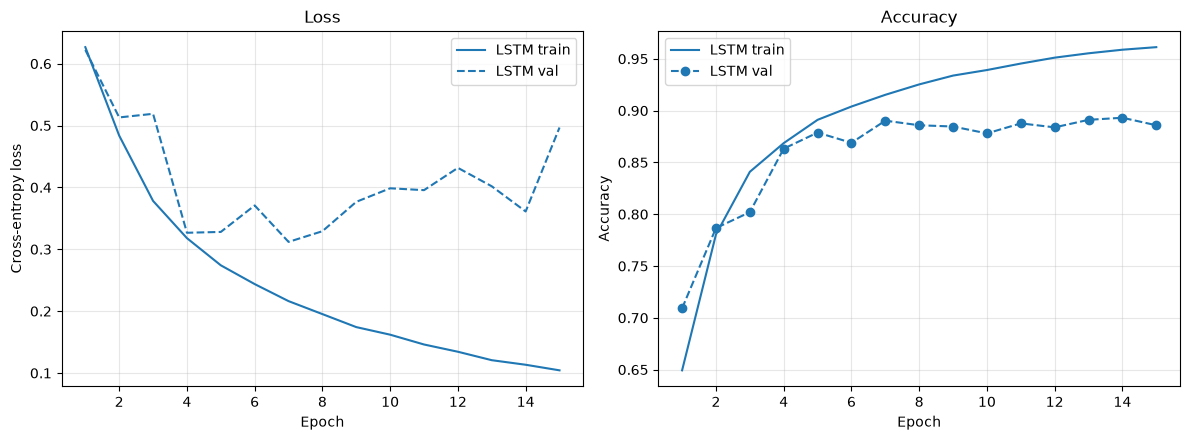

== LSTM 測試集結果 ==
{'Accuracy': 0.8909, 'Precision': 0.8915, 'Recall': 0.8908, 'F1': 0.8908, 'AUC': 0.9507}
              precision    recall  f1-score   support

    negative     0.9064    0.8709    0.8883      2470
    positive     0.8766    0.9108    0.8934      2489

    accuracy                         0.8909      4959
   macro avg     0.8915    0.8908    0.8908      4959
weighted avg     0.8915    0.8909    0.8909      4959



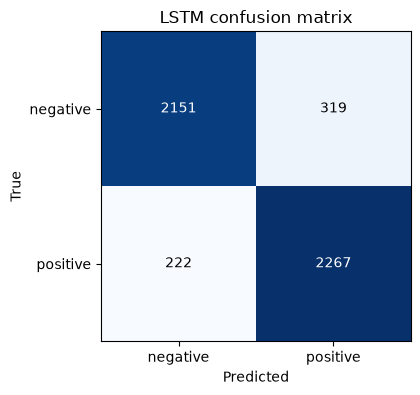

In [4]:
lstm = build_model(LSTMClassifier)
print(lstm)
print("trainable params:", f"{count_parameters(lstm):,}")

set_seed(42)
lstm_hist = train_classifier(
    lstm, train_loader, val_loader, device,
    epochs=CFG["epochs"], lr=CFG["lr"], clip=CFG["clip"],
    ckpt_path=RESULT / "lstm_best.pt", name="LSTM",
)
print(f"best epoch {lstm_hist['best_epoch']} | val acc {lstm_hist['best_val_acc']:.4f} | total {lstm_hist['total_time']:.0f}s")
plot_history({"LSTM": lstm_hist}, RESULT / "lstm_curves.png")

lstm_metrics = evaluate_model("LSTM", lstm)

### RNN 與 LSTM 表現比較

,Accuracy,Precision,Recall,F1,AUC,Params,Train time (s),Inference time (s)
RNN,0.8294,0.8305,0.8293,0.8292,0.9000,2593282.0,320.8729,0.5860
LSTM,0.8909,0.8915,0.8908,0.8908,0.9507,2692354.0,349.6063,0.6335


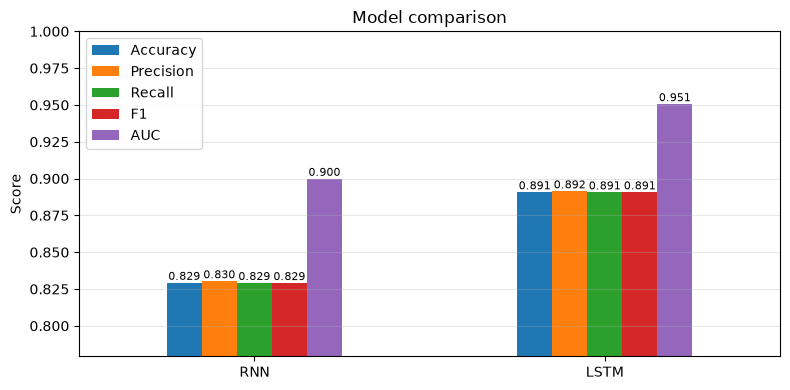

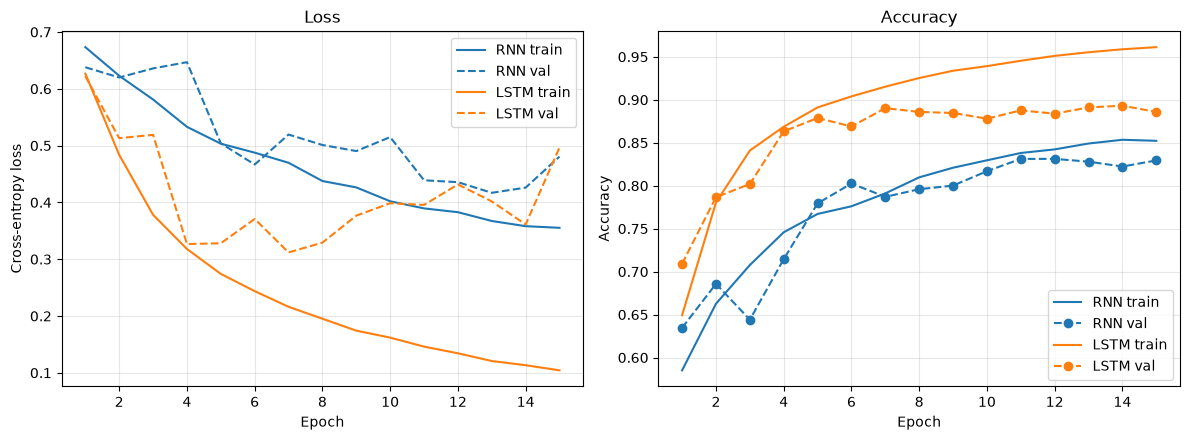

In [5]:
results = {
    "RNN": dict(metrics=rnn_metrics, params=count_parameters(rnn),
                train_time=rnn_hist["total_time"], infer_time=measure_inference_time(rnn, test_loader, device)),
    "LSTM": dict(metrics=lstm_metrics, params=count_parameters(lstm),
                 train_time=lstm_hist["total_time"], infer_time=measure_inference_time(lstm, test_loader, device)),
}
table = compare_models(results)
display(table.round(4))

table.to_csv(RESULT / "comparison.csv")
with open(RESULT / "histories.json", "w") as f:
    json.dump({"RNN": rnn_hist, "LSTM": lstm_hist}, f, indent=1)

plot_metric_bars(table, save_path=RESULT / "comparison_bars.png")
plot_history({"RNN": rnn_hist, "LSTM": lstm_hist}, RESULT / "curves_compare.png")

- LTSM 在各項評估指標方面都明顯高於 RNN
- LSTM 收斂速度很快，後期有過擬合的跡象

## Quiz 3: Vision Transformer 

共10個類別，飛機、汽車、鳥、貓、鹿、狗、青蛙、馬、船、卡車  
訓練集：45000，一個類別4500筆  
驗證集：5000，一個類別500筆  
測試集：10000，一個類別1000筆  

In [6]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.data_loader import IMAGENET_MEAN, IMAGENET_STD, ROOT, load_vision_data, set_seed
from src.eval_metrics import (
    classification_metrics,
    compare_models,
    per_class_auc,
    plot_confusion_matrix,
    plot_history,
    plot_metric_bars,
    plot_per_class_auc,
    plot_roc_curves,
    print_report,
    show_image_predictions,
)
from src.models import build_resnet, build_vit
from src.train import count_parameters, get_device, measure_inference_time, predict, train_classifier

RESULT = ROOT / "result" / "quiz3"
RESULT.mkdir(parents=True, exist_ok=True)
device = get_device()
print("device:", device)

CFG = dict( # 這裡調參
    batch_size=32, size=224, num_workers=2,       # 資料（記憶體不足時把 batch_size 調小）
    epochs=5, clip=1.0, weight_decay=0.01,        # 訓練
    vit_lr=5e-5, resnet_lr=3e-4,                  # 各模型的微調學習率
)

train_loader, val_loader, test_loader, class_names = load_vision_data(
    CFG["batch_size"], CFG["size"], CFG["num_workers"]
)
print("classes:", class_names)
print("train / val / test =", len(train_loader.dataset), "/", len(val_loader.dataset), "/", len(test_loader.dataset))

device: cuda


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train / val / test = 45000 / 5000 / 10000


### 資料檢視

In [7]:
train_t = np.array(train_loader.dataset.dataset.targets)[train_loader.dataset.indices]
val_t = np.array(val_loader.dataset.dataset.targets)[val_loader.dataset.indices]
test_t = np.array(test_loader.dataset.targets)
counts = pd.DataFrame(
    {"train": np.bincount(train_t), "val": np.bincount(val_t), "test": np.bincount(test_t)}, index=class_names
)
counts.loc["total"] = counts.sum()
display(counts)

,train,val,test
airplane,4500,500,1000
automobile,4500,500,1000
bird,4500,500,1000
cat,4500,500,1000
deer,4500,500,1000
dog,4500,500,1000
frog,4500,500,1000
horse,4500,500,1000
ship,4500,500,1000
truck,4500,500,1000


### 微調 Vision Transformer(ViT)

trainable params: 85,806,346


[ViT] epoch 01/5 | train loss 0.2092 acc 0.9358 | val loss 0.1389 acc 0.9580 | 168.6s


[ViT] epoch 02/5 | train loss 0.1005 acc 0.9681 | val loss 0.1146 acc 0.9672 | 169.0s


[ViT] epoch 03/5 | train loss 0.0466 acc 0.9869 | val loss 0.0919 acc 0.9774 | 168.1s


[ViT] epoch 04/5 | train loss 0.0160 acc 0.9954 | val loss 0.0676 acc 0.9828 | 167.7s


[ViT] epoch 05/5 | train loss 0.0039 acc 0.9988 | val loss 0.0619 acc 0.9852 | 167.8s
best epoch 5 | val acc 0.9852 | total 842s


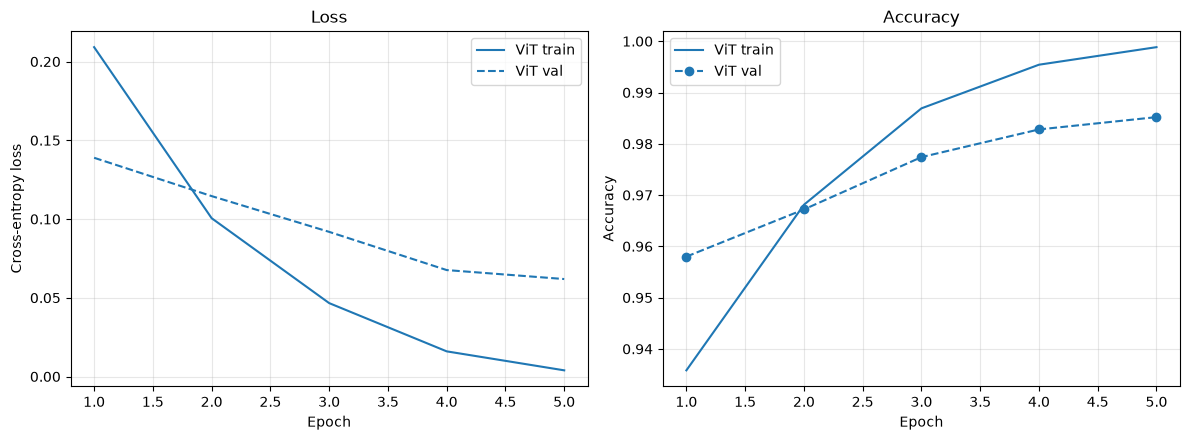

In [8]:
set_seed(42)
vit = build_vit(num_classes=len(class_names), pretrained=True)
print("trainable params:", f"{count_parameters(vit):,}")

vit_hist = train_classifier(
    vit, train_loader, val_loader, device,
    epochs=CFG["epochs"], lr=CFG["vit_lr"], weight_decay=CFG["weight_decay"], clip=CFG["clip"],
    amp=True, cosine=True, ckpt_path=RESULT / "vit_best.pt", name="ViT",
)
print(f"best epoch {vit_hist['best_epoch']} | val acc {vit_hist['best_val_acc']:.4f} | total {vit_hist['total_time']:.0f}s")
plot_history({"ViT": vit_hist}, RESULT / "vit_curves.png")

### 以測試集作測試並呈現結果

== ViT-B/16 測試集結果 ==
{'Accuracy': 0.9823, 'Precision': 0.9823, 'Recall': 0.9823, 'F1': 0.9823, 'Macro-AUC': 0.9996}
              precision    recall  f1-score   support

    airplane     0.9889    0.9840    0.9865      1000
  automobile     0.9772    0.9870    0.9821      1000
        bird     0.9939    0.9800    0.9869      1000
         cat     0.9621    0.9650    0.9636      1000
        deer     0.9802    0.9890    0.9846      1000
         dog     0.9718    0.9660    0.9689      1000
        frog     0.9920    0.9940    0.9930      1000
       horse     0.9860    0.9880    0.9870      1000
        ship     0.9861    0.9930    0.9895      1000
       truck     0.9849    0.9770    0.9809      1000

    accuracy                         0.9823     10000
   macro avg     0.9823    0.9823    0.9823     10000
weighted avg     0.9823    0.9823    0.9823     10000



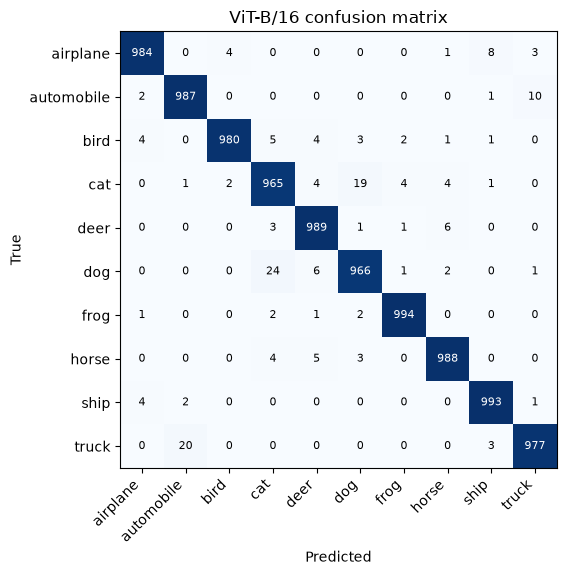

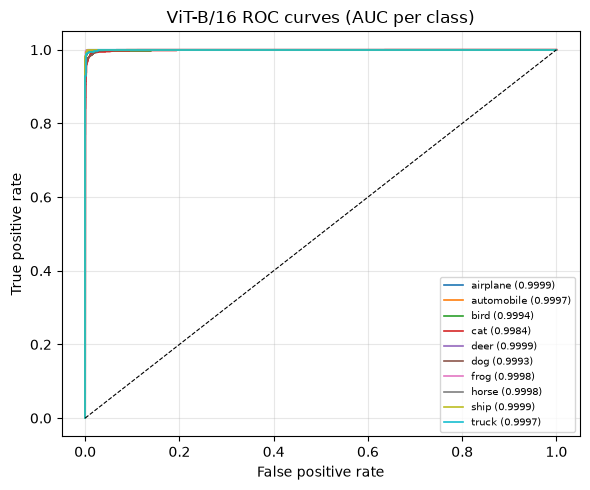

In [9]:
def evaluate_model(name, tag, model):
    """對測試集推論，顯示並儲存結果，回傳 (指標, y_true, y_pred, probs)。"""
    y_true, y_pred, probs = predict(model, test_loader, device, amp=True)
    metrics = classification_metrics(y_true, y_pred, probs)
    print(f"== {name} 測試集結果 ==")
    print({k: round(v, 4) for k, v in metrics.items()})
    print_report(y_true, y_pred, class_names)
    plot_confusion_matrix(y_true, y_pred, class_names, f"{name} confusion matrix", RESULT / f"{tag}_confusion.png")
    plot_roc_curves(y_true, probs, class_names, f"{name} ROC curves (AUC per class)", RESULT / f"{tag}_roc.png")

    rng = np.random.RandomState(0)
    ds = test_loader.dataset
    # show_image_predictions(ds, y_true, y_pred, probs, class_names, rng.choice(len(ds), 12, replace=False),
    #                        f"{name}: random test samples", RESULT / f"{tag}_samples.png")
    wrong = np.where(y_true != y_pred)[0]
    # if len(wrong):
    #     show_image_predictions(ds, y_true, y_pred, probs, class_names, rng.choice(wrong, min(12, len(wrong)), replace=False),
    #                            f"{name}: misclassified samples", RESULT / f"{tag}_errors.png")
    pd.DataFrame({"index": np.arange(len(y_true)), "true": [class_names[i] for i in y_true],
                  "pred": [class_names[i] for i in y_pred], "confidence": probs.max(1)}
                 ).to_csv(RESULT / f"{tag}_predictions.csv", index=False)
    return metrics, y_true, y_pred, probs


vit_metrics, y_true, vit_pred, vit_probs = evaluate_model("ViT-B/16", "vit", vit)

### 微調 ResNet 並以測試集做測試

trainable params: 23,528,522


Epoch [Train]:  18%|█▊        | 260/1407 [00:14<01:16, 14.96it/s]

[ResNet50] epoch 01/5 | train loss 0.4213 acc 0.8601 | val loss 0.2861 acc 0.9024 | 83.4s


[ResNet50] epoch 02/5 | train loss 0.2202 acc 0.9258 | val loss 0.1996 acc 0.9352 | 81.8s


[ResNet50] epoch 03/5 | train loss 0.1206 acc 0.9590 | val loss 0.1311 acc 0.9598 | 82.2s


[ResNet50] epoch 04/5 | train loss 0.0532 acc 0.9817 | val loss 0.1144 acc 0.9652 | 81.2s


[ResNet50] epoch 05/5 | train loss 0.0251 acc 0.9915 | val loss 0.1106 acc 0.9686 | 83.1s
best epoch 5 | val acc 0.9686 | total 412s


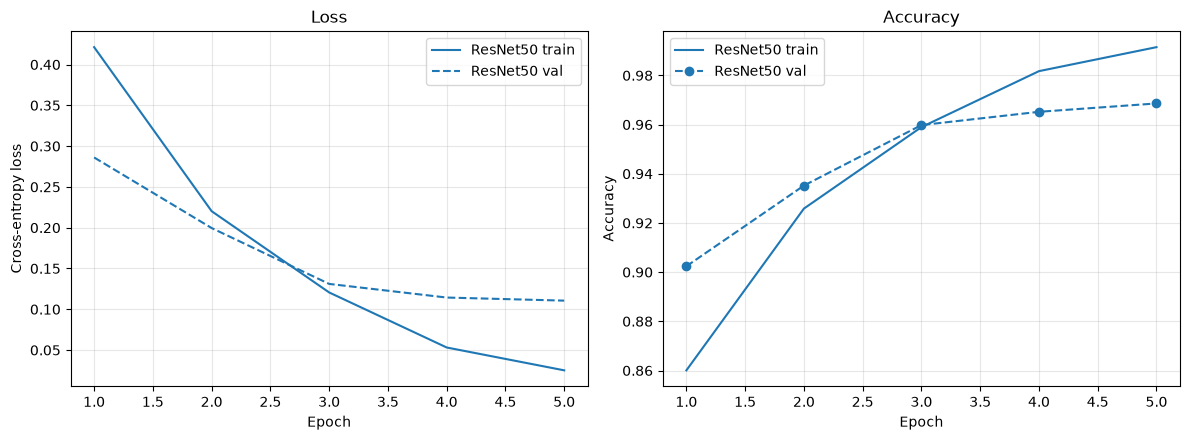

== ResNet50 測試集結果 ==
{'Accuracy': 0.9693, 'Precision': 0.9693, 'Recall': 0.9693, 'F1': 0.9693, 'Macro-AUC': 0.9993}
              precision    recall  f1-score   support

    airplane     0.9692    0.9750    0.9721      1000
  automobile     0.9772    0.9860    0.9816      1000
        bird     0.9737    0.9610    0.9673      1000
         cat     0.9355    0.9280    0.9317      1000
        deer     0.9618    0.9810    0.9713      1000
         dog     0.9462    0.9490    0.9476      1000
        frog     0.9849    0.9770    0.9809      1000
       horse     0.9880    0.9870    0.9875      1000
        ship     0.9741    0.9770    0.9755      1000
       truck     0.9828    0.9720    0.9774      1000

    accuracy                         0.9693     10000
   macro avg     0.9693    0.9693    0.9693     10000
weighted avg     0.9693    0.9693    0.9693     10000



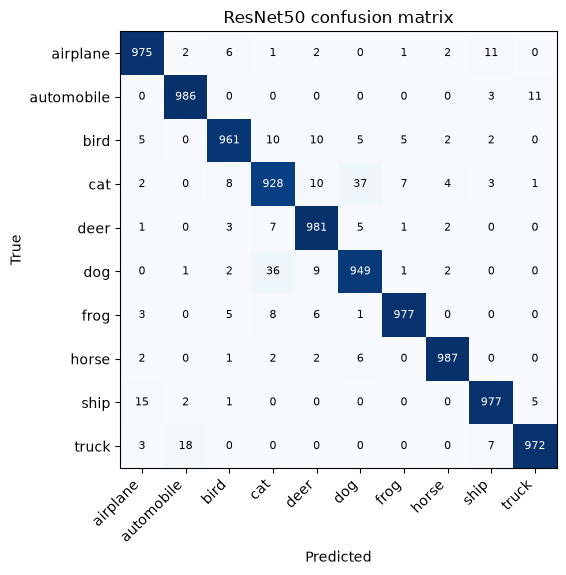

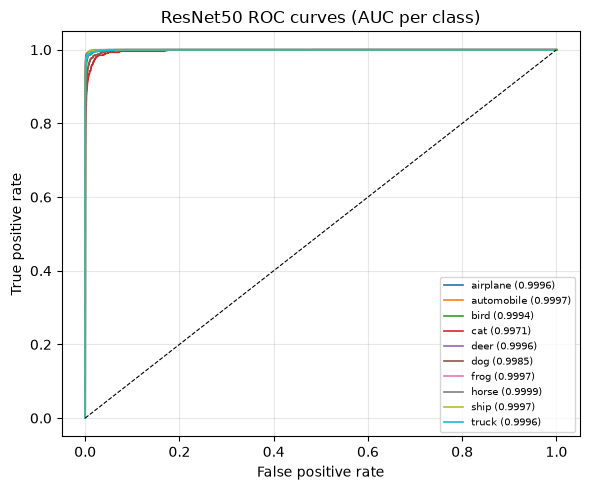

In [10]:
set_seed(42)
resnet = build_resnet(num_classes=len(class_names), pretrained=True, arch="resnet50")
print("trainable params:", f"{count_parameters(resnet):,}")

resnet_hist = train_classifier(
    resnet, train_loader, val_loader, device,
    epochs=CFG["epochs"], lr=CFG["resnet_lr"], weight_decay=CFG["weight_decay"], clip=CFG["clip"],
    amp=True, cosine=True, ckpt_path=RESULT / "resnet_best.pt", name="ResNet50",
)
print(f"best epoch {resnet_hist['best_epoch']} | val acc {resnet_hist['best_val_acc']:.4f} | total {resnet_hist['total_time']:.0f}s")
plot_history({"ResNet50": resnet_hist}, RESULT / "resnet_curves.png")

resnet_metrics, _, resnet_pred, resnet_probs = evaluate_model("ResNet50", "resnet", resnet)

### ViT 與 ResNet 的 Macro-AUC 表現比較

,Accuracy,Precision,Recall,F1,Macro-AUC,Params,Train time (s),Inference time (s)
ViT-B/16,0.9823,0.9823,0.9823,0.9823,0.9996,85806346.0,842.4220,12.4237
ResNet50,0.9693,0.9693,0.9693,0.9693,0.9993,23528522.0,412.0871,11.6804


Macro-AUC  ViT: 0.9996 | ResNet50: 0.9993 | 差距 (ViT - ResNet): +0.0003


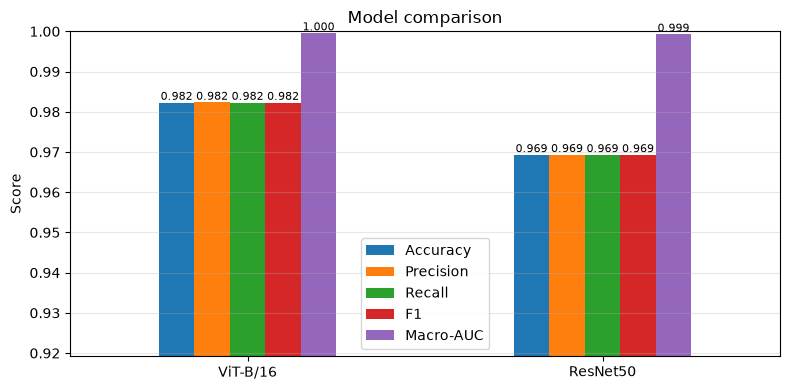

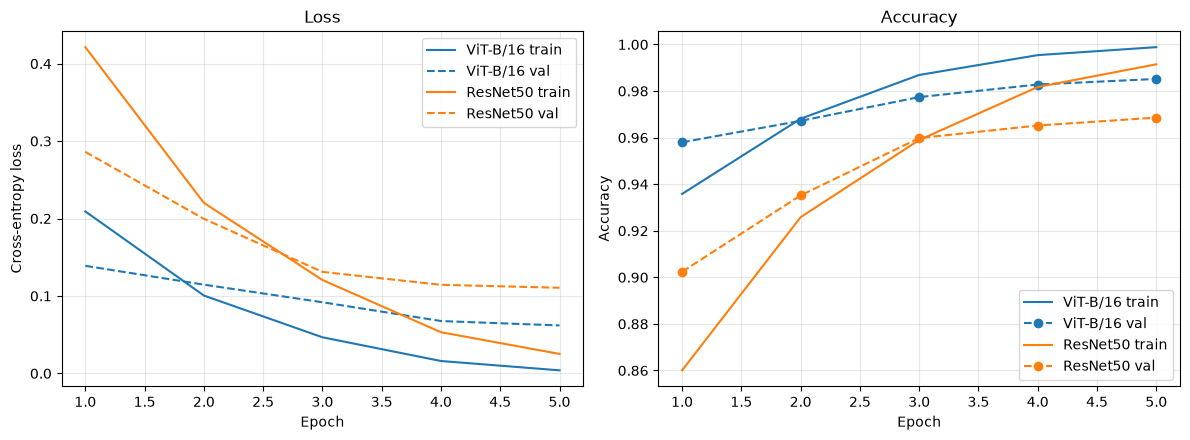

In [11]:
results = {
    "ViT-B/16": dict(metrics=vit_metrics, params=count_parameters(vit), train_time=vit_hist["total_time"],
                     infer_time=measure_inference_time(vit, test_loader, device, amp=True)),
    "ResNet50": dict(metrics=resnet_metrics, params=count_parameters(resnet), train_time=resnet_hist["total_time"],
                     infer_time=measure_inference_time(resnet, test_loader, device, amp=True)),
}
table = compare_models(results)
display(table.round(4))
table.to_csv(RESULT / "comparison.csv")
with open(RESULT / "histories.json", "w") as f:
    json.dump({"ViT-B/16": vit_hist, "ResNet50": resnet_hist}, f, indent=1)

print(f"Macro-AUC  ViT: {vit_metrics['Macro-AUC']:.4f} | ResNet50: {resnet_metrics['Macro-AUC']:.4f} "
      f"| 差距 (ViT - ResNet): {vit_metrics['Macro-AUC'] - resnet_metrics['Macro-AUC']:+.4f}")

plot_metric_bars(table, save_path=RESULT / "comparison_bars.png")
plot_history({"ViT-B/16": vit_hist, "ResNet50": resnet_hist}, RESULT / "curves_compare.png")

,ViT-B/16,ResNet50,ViT - ResNet
airplane,0.9999,0.9996,0.0002
automobile,0.9997,0.9997,-0.0001
bird,0.9994,0.9994,0.0001
cat,0.9984,0.9971,0.0013
deer,0.9999,0.9996,0.0003
dog,0.9993,0.9985,0.0008
frog,0.9998,0.9997,0.0001
horse,0.9998,0.9999,-0.0000
ship,0.9999,0.9997,0.0002
truck,0.9997,0.9996,0.0001


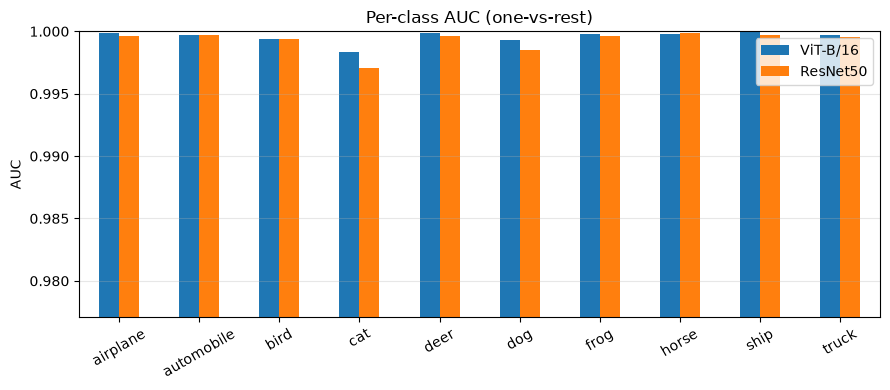

In [12]:
pc = pd.DataFrame({
    "ViT-B/16": per_class_auc(y_true, vit_probs, class_names),
    "ResNet50": per_class_auc(y_true, resnet_probs, class_names),
})
pc["ViT - ResNet"] = pc["ViT-B/16"] - pc["ResNet50"]
pc.loc["Macro (mean)"] = pc.mean()
display(pc.round(4))
pc.to_csv(RESULT / "per_class_auc.csv")
plot_per_class_auc(pc.drop(columns="ViT - ResNet").drop(index="Macro (mean)"), RESULT / "per_class_auc.png")

### 結果分析

- 在相同的微調設定下，ViT 的表徵能力與上限均顯著優於 ResNet
- ViT 的 Accuracy、Precision、Recall、F1及Macro-AUC皆高於 ResNet
- ViT 在各類別的判斷也都略比 ResNet 準確	

## Quiz 4: Image Captioning

In [13]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.caption_data import describe_splits, prepare_caption_data
from src.data_loader import ROOT, set_seed
from src.eval_caption import (
    DEFAULT_GEMINI_MODEL,
    check_gemini,
    evaluate_captions,
    gemini_caption_batch,
    gemini_judge_batch,
    get_gemini_client,
    latency_stats,
    plot_caption_examples,
    plot_caption_history,
    plot_method_comparison,
    summarize_judgements,
)
from src.models.captioning import build_decoder
from src.train_caption import CaptionPipeline, generate_captions, time_pipeline, train_caption

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)

RESULT = ROOT / "result" / "quiz4"
RESULT.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

CFG = dict(
    pretrained=True,
    encoder="resnet50", compare_encoder="vit_b_16",   # 主要模型與 4-4 對照的編碼器
    batch_size=64, num_workers=2,
    embed_dim=256, hidden_dim=512, dropout=0.5,       # 解碼器
    epochs=15, lr=5e-4, clip=5.0, patience=4,         # 訓練（驗證 loss 連續 patience 次沒進步就停止）
    max_len=20, beam_size=3,                          # 生成
    use_bertscore=False, bertscore_model=None,         # None = roberta-large；想快一點可改 "distilbert-base-uncased"
    gemini_model=DEFAULT_GEMINI_MODEL,
    n_gemini=30, gemini_sleep=2.0,                    # Gemini 使用的影像張數與每次呼叫間隔（秒），依你的額度調整
    n_latency=100,                                    # 量測回覆時間的影像張數
)

device: cuda


### 資料檢視

,圖片數,描述句數,每張圖平均句數,平均句長(字),最長句(字)
train,6000.0,30000.0,5.0,10.82,37.0
val,1000.0,5000.0,5.0,10.93,33.0
test,1000.0,5000.0,5.0,10.87,31.0


詞彙表大小: 3480 | 訓練用（圖,句）配對數: 30000


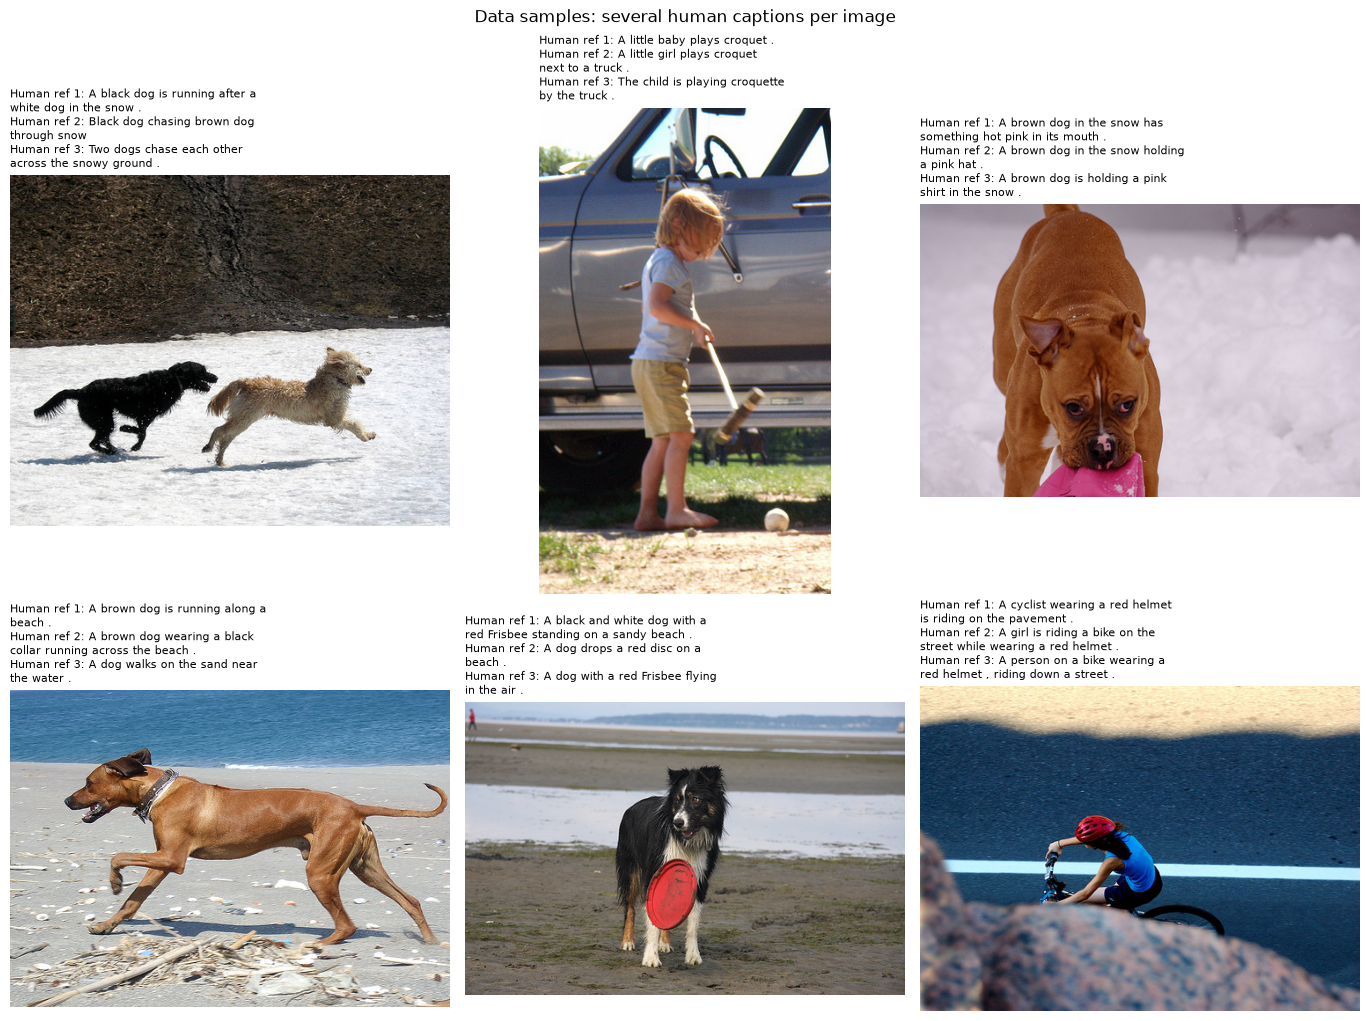

In [14]:
set_seed(42)
data = prepare_caption_data(CFG["encoder"], device, CFG["batch_size"], CFG["pretrained"], num_workers=CFG["num_workers"])
splits, images_dir, vocab = data["splits"], data["images_dir"], data["vocab"]
test_records = splits["test"]
test_refs = [r["captions"] for r in test_records]

display(describe_splits(splits))
print("詞彙表大小:", len(vocab), "| 訓練用（圖,句）配對數:", len(data["train_loader"].dataset))

rows = [{"image": r["image"], "lines": [(f"Human ref {k + 1}", c) for k, c in enumerate(r["captions"][:3])]}
        for r in splits["train"][:6]]
plot_caption_examples(images_dir, rows, title="Data samples: several human captions per image", save_path=RESULT / "data_samples.png")

### 訓練 Image Captioning 模型

模型：ResNet50 (凍結) + LSTM 解碼器

解碼器參數量: 7,404,184
[resnet50] epoch 01/15 | train loss 4.312 acc 0.267 | val loss 3.573 ppl 35.6 acc 0.331 | 5.8s
[resnet50] epoch 02/15 | train loss 3.469 acc 0.341 | val loss 3.231 ppl 25.3 acc 0.360 | 5.8s
[resnet50] epoch 03/15 | train loss 3.167 acc 0.368 | val loss 3.078 ppl 21.7 acc 0.374 | 5.8s


[resnet50] epoch 04/15 | train loss 2.970 acc 0.388 | val loss 2.987 ppl 19.8 acc 0.382 | 5.8s
[resnet50] epoch 05/15 | train loss 2.822 acc 0.403 | val loss 2.939 ppl 18.9 acc 0.387 | 5.8s
[resnet50] epoch 06/15 | train loss 2.703 acc 0.416 | val loss 2.899 ppl 18.2 acc 0.391 | 5.8s
[resnet50] epoch 07/15 | train loss 2.604 acc 0.428 | val loss 2.880 ppl 17.8 acc 0.393 | 5.8s
[resnet50] epoch 08/15 | train loss 2.519 acc 0.438 | val loss 2.862 ppl 17.5 acc 0.397 | 5.9s
[resnet50] epoch 09/15 | train loss 2.445 acc 0.447 | val loss 2.859 ppl 17.4 acc 0.398 | 5.8s
[resnet50] epoch 10/15 | train loss 2.380 acc 0.454 | val loss 2.850 ppl 17.3 acc 0.400 | 5.8s
[resnet50] epoch 11/15 | train loss 2.324 acc 0.461 | val loss 2.859 ppl 17.5 acc 0.399 | 6.0s
[resnet50] epoch 12/15 | train loss 2.270 acc 0.468 | val loss 2.863 ppl 17.5 acc 0.399 | 5.8s
[resnet50] epoch 13/15 | train loss 2.182 acc 0.480 | val loss 2.861 ppl 17.5 acc 0.401 | 5.9s
[resnet50] epoch 14/15 | train loss 2.144 acc 0.48

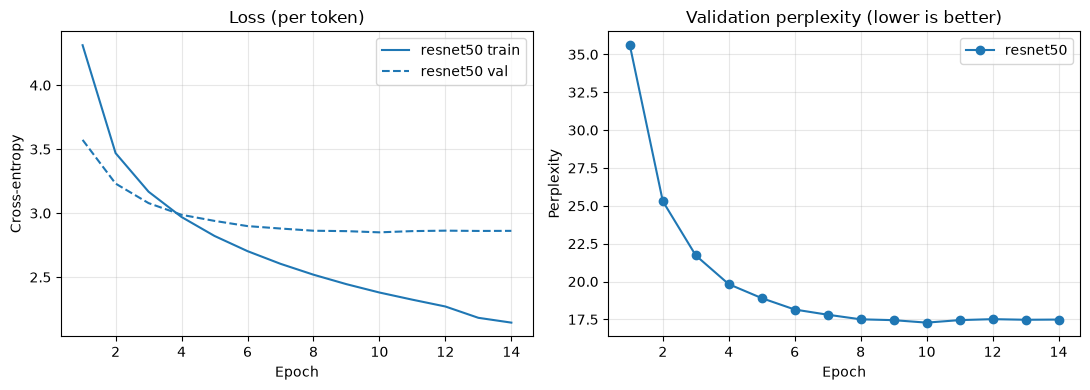

In [15]:
set_seed(42)
dec_main = build_decoder(vocab, data["feat_dim"], CFG["embed_dim"], CFG["hidden_dim"], CFG["dropout"])
print("解碼器參數量:", f"{sum(p.numel() for p in dec_main.parameters()):,}")

hist_main = train_caption(
    dec_main, data["train_loader"], data["val_loader"], device,
    epochs=CFG["epochs"], lr=CFG["lr"], clip=CFG["clip"], patience=CFG["patience"],
    ckpt_path=RESULT / f"caption_{CFG['encoder']}.pt", name=CFG["encoder"],
)
print(f"best epoch {hist_main['best_epoch']} | val loss {hist_main['best_val_loss']:.3f} | 訓練時間 {hist_main['total_time']:.0f}s")
plot_caption_history({CFG["encoder"]: hist_main}, RESULT / "training_curves.png")

### 產生影像描述

隨機抽取 6 張圖片將模型生成結果與人類真實標註（Ground Truth）繪圖並列可視化

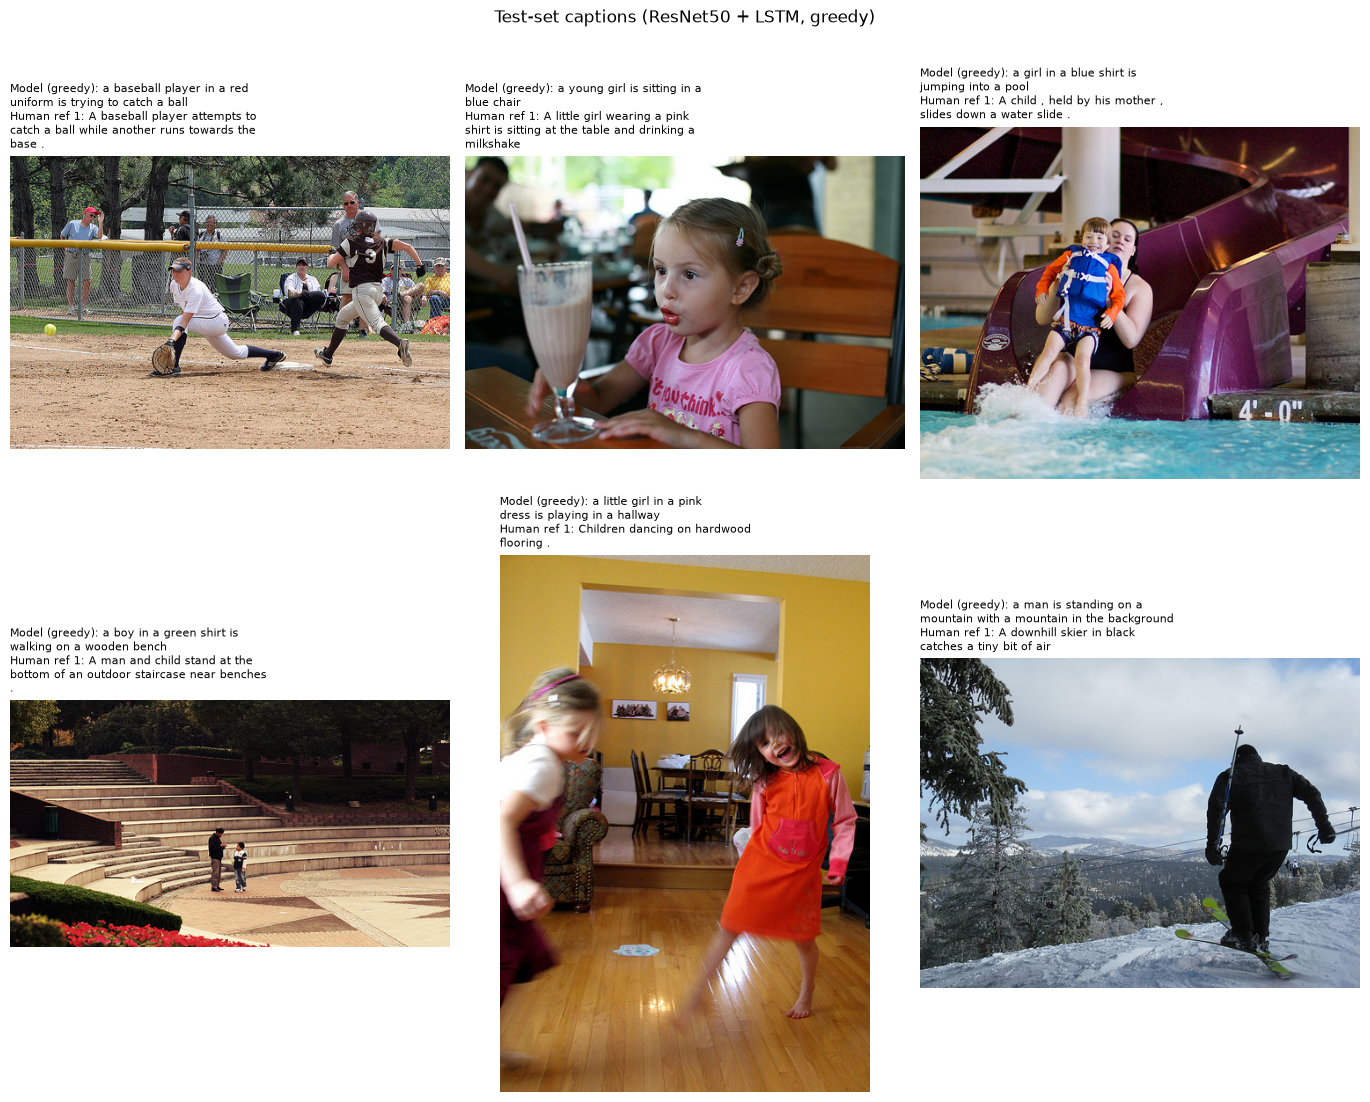

In [16]:
main_caps = generate_captions(dec_main, data["feats"]["test"], vocab, device, "greedy", max_len=CFG["max_len"])

pd.DataFrame({"image": [r["image"] for r in test_records], "caption": main_caps}
             ).to_csv(RESULT / "test_captions_main.csv", index=False)

show_idx = np.random.RandomState(0).choice(len(test_records), 6, replace=False)
rows = [{"image": test_records[i]["image"], "lines": [("Model (greedy)", main_caps[i]), ("Human ref 1", test_refs[i][0])]}
        for i in show_idx]
plot_caption_examples(images_dir, rows, title="Test-set captions (ResNet50 + LSTM, greedy)", save_path=RESULT / "test_samples.png")

### 使用 Gemini 判斷模型產生的描述是否符合影像內容

把「影像 + 模型產生的描述」交給 Gemini，請它回答 `match`（是否符合）、`score`（1–5 分）與簡短理由。為了控制 API 用量，只抽樣 `n_gemini` 張測試影像

**對照組**：同一批影像配上「別張圖的描述」，理論上應該被判為不符合。若對照組的符合比例很低，才能說明 Gemini 的判斷有鑑別力，而不是什麼描述都說符合。

In [17]:
client = get_gemini_client("AQ.Ab8RN6Lju9fcMcME6NWM0G01PKtNCtLc_nDg-o98qRC5fSAsgA")   # 讀環境變數 GEMINI_API_KEY / Colab 密鑰；都沒有時會提示輸入
# 先確認 key 與模型可用；若指定的模型已下架 / 不存在，會自動改用目前可用的 flash 模型，失敗時會直接顯示真正的錯誤
CFG["gemini_model"] = check_gemini(client, CFG["gemini_model"])

gem_idx = np.random.RandomState(1).choice(len(test_records), min(CFG["n_gemini"], len(test_records)), replace=False)
gem_paths = [images_dir / test_records[i]["image"] for i in gem_idx]

judge_df = gemini_judge_batch(client, [(p, main_caps[i]) for p, i in zip(gem_paths, gem_idx)],
                              model=CFG["gemini_model"], sleep=CFG["gemini_sleep"])
ctrl_df = gemini_judge_batch(client, [(p, main_caps[gem_idx[(k + 1) % len(gem_idx)]]) for k, p in enumerate(gem_paths)],
                             model=CFG["gemini_model"], sleep=CFG["gemini_sleep"])

judge_summary = pd.DataFrame([summarize_judgements(judge_df, "模型生成的描述"),
                              summarize_judgements(ctrl_df, "對照組：配錯圖片的描述")])
display(judge_summary.round(3))
judge_df.to_csv(RESULT / "gemini_judgements.csv", index=False)
ctrl_df.to_csv(RESULT / "gemini_judgements_control.csv", index=False)

Gemini 連線正常：使用模型 gemini-3.1-flash-lite（測試呼叫 0.73s）
[Gemini 判斷] 10/30

[Gemini 判斷] 30/30
[Gemini 判斷] 30/30


,對象,判斷張數,失敗張數,符合比例,平均分數(1-5),平均耗時(s)
0,模型生成的描述,30,0,0.133,2.033,5.533
1,對照組：配錯圖片的描述,30,0,0.000,1.000,2.603


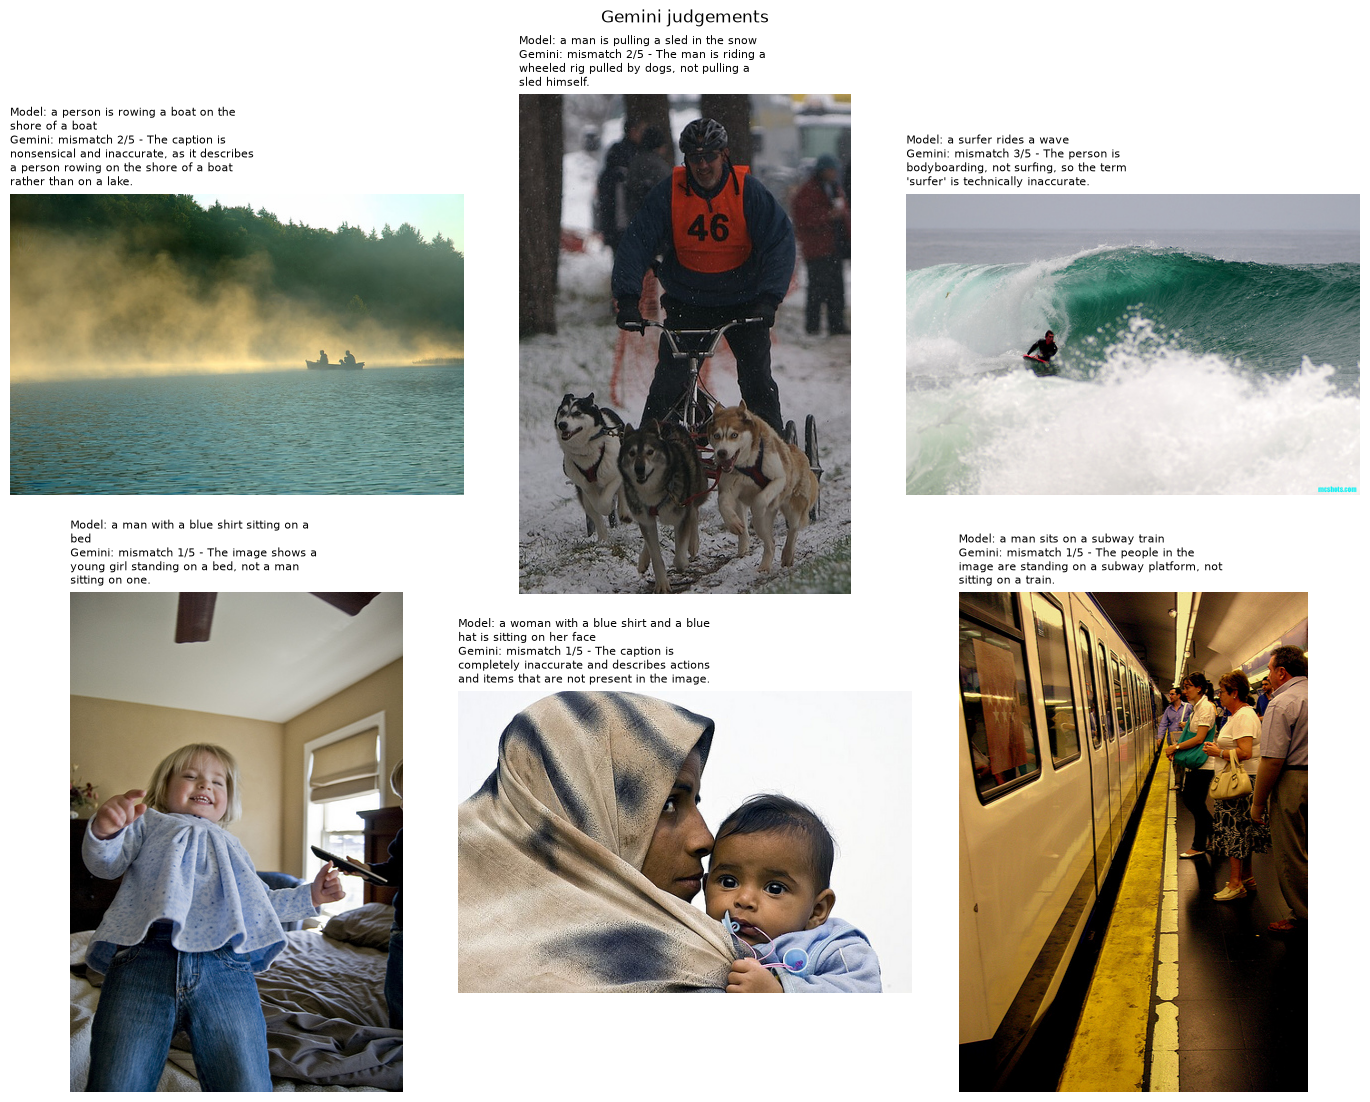

,image,caption,score,reason
0,215214751_e913b6ff09.jpg,a person is rowing a boat on the shore of a boat,2,"The caption is nonsensical and inaccurate, as ..."
1,2358561039_e215a8d6cd.jpg,a man is pulling a sled in the snow,2,The man is riding a wheeled rig pulled by dogs...
2,3624327440_bef4f33f32.jpg,a surfer rides a wave,3,"The person is bodyboarding, not surfing, so th..."
3,2354540393_a149722680.jpg,a man with a blue shirt sitting on a bed,1,The image shows a young girl standing on a bed...
4,3201427741_3033f5b625.jpg,a woman with a blue shirt and a blue hat is si...,1,The caption is completely inaccurate and descr...
5,2981702521_2459f2c1c4.jpg,a man sits on a subway train,1,The people in the image are standing on a subw...
6,3582742297_1daa29968e.jpg,two dogs are running in a field,3,"There are three dogs in the image, not two."
7,1339596997_8ac29c1841.jpg,a woman in a pink dress and a white hat is sta...,1,The caption incorrectly identifies the clothin...
8,302983277_69a4e732e4.jpg,a man is sitting on a snowy mountain,2,"The man is sitting on a horse, not on the moun..."
9,1352410176_af6b139734.jpg,a man is walking on a beach,1,"The subject in the image is a young girl, not ..."


In [18]:
rows = []
for k in range(min(6, len(judge_df))):
    r = judge_df.iloc[k]
    verdict = "(judge failed)" if pd.isna(r["match"]) else f"{'match' if r['match'] else 'mismatch'} {int(r['score'])}/5 - {r['reason']}"
    rows.append({"image": r["image"], "lines": [("Model", r["caption"]), ("Gemini", verdict)]})
plot_caption_examples(images_dir, rows, title="Gemini judgements", save_path=RESULT / "gemini_judge_samples.png")

display(judge_df[judge_df["match"].eq(False)][["image", "caption", "score", "reason"]])

### 透過 BLEU 量化模型表現

In [19]:
main_scores = evaluate_captions(main_caps, test_refs, bertscore=CFG["use_bertscore"],
                                bertscore_model=CFG["bertscore_model"], device=str(device))
score_tbl = pd.Series(main_scores).to_frame(f"{CFG['encoder']} + LSTM (greedy)").T
display(score_tbl.round(4))
score_tbl.to_csv(RESULT / "scores_main.csv")

,BLEU-1,BLEU-2,BLEU-3,BLEU-4
resnet50 + LSTM (greedy),0.6215,0.4452,0.3079,0.2109


### 比較不同方法的回覆時間與表現
比較的「方法」：

| 方法 | 說明 |
|---|---|
| ResNet50 + LSTM / greedy | 上面訓練的主要模型，逐步取最高機率的字 |
| ResNet50 + LSTM / beam | 同一個模型，改用 beam search 解碼 |
| ViT-B/16 + LSTM / greedy、beam | 換成 ViT 編碼器（解碼器、資料、超參數相同，重新訓練） |
| Gemini zero-shot | 不訓練，直接請 Gemini 為影像寫一句描述 |


[vit_b_16] epoch 01/15 | train loss 4.319 acc 0.267 | val loss 3.590 ppl 36.3 acc 0.330 | 5.8s
[vit_b_16] epoch 02/15 | train loss 3.500 acc 0.338 | val loss 3.266 ppl 26.2 acc 0.355 | 5.8s
[vit_b_16] epoch 03/15 | train loss 3.204 acc 0.364 | val loss 3.113 ppl 22.5 acc 0.369 | 5.8s
[vit_b_16] epoch 04/15 | train loss 3.016 acc 0.382 | val loss 3.025 ppl 20.6 acc 0.377 | 5.8s
[vit_b_16] epoch 05/15 | train loss 2.870 acc 0.396 | val loss 2.963 ppl 19.4 acc 0.383 | 5.9s
[vit_b_16] epoch 06/15 | train loss 2.755 acc 0.409 | val loss 2.930 ppl 18.7 acc 0.385 | 5.8s
[vit_b_16] epoch 07/15 | train loss 2.656 acc 0.420 | val loss 2.897 ppl 18.1 acc 0.391 | 5.8s
[vit_b_16] epoch 08/15 | train loss 2.571 acc 0.430 | val loss 2.885 ppl 17.9 acc 0.393 | 5.9s
[vit_b_16] epoch 09/15 | train loss 2.499 acc 0.439 | val loss 2.879 ppl 17.8 acc 0.395 | 5.7s
[vit_b_16] epoch 10/15 | train loss 2.432 acc 0.446 | val loss 2.876 ppl 17.7 acc 0.395 | 5.9s
[vit_b_16] epoch 11/15 | train loss 2.373 acc 0.45

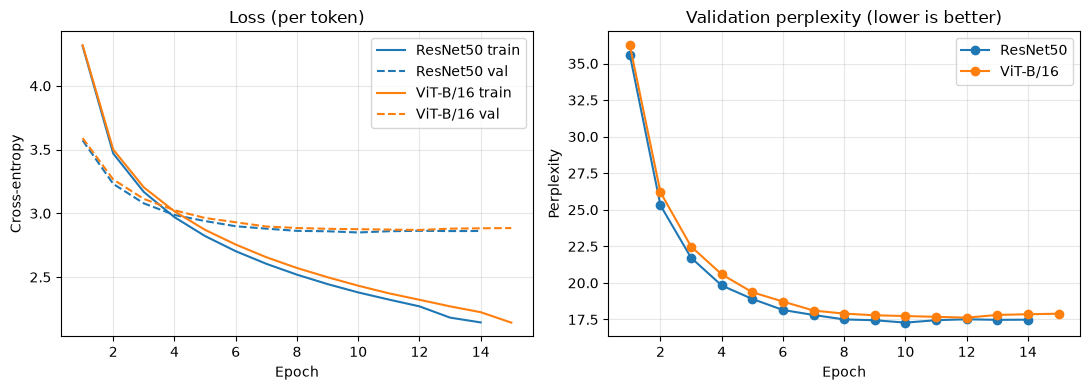

In [20]:
set_seed(42)
data_vit = prepare_caption_data(CFG["compare_encoder"], device, CFG["batch_size"], CFG["pretrained"], num_workers=CFG["num_workers"])
assert data_vit["vocab"].itos == vocab.itos, "兩個實驗的詞彙表必須相同"

dec_vit = build_decoder(vocab, data_vit["feat_dim"], CFG["embed_dim"], CFG["hidden_dim"], CFG["dropout"])
hist_vit = train_caption(
    dec_vit, data_vit["train_loader"], data_vit["val_loader"], device,
    epochs=CFG["epochs"], lr=CFG["lr"], clip=CFG["clip"], patience=CFG["patience"],
    ckpt_path=RESULT / f"caption_{CFG['compare_encoder']}.pt", name=CFG["compare_encoder"],
)
plot_caption_history({"ResNet50": hist_main, "ViT-B/16": hist_vit}, RESULT / "training_curves_compare.png")
with open(RESULT / "histories.json", "w") as f:
    json.dump({"resnet50": hist_main, "vit_b_16": hist_vit}, f, indent=1)

In [21]:
methods = {   # 名稱: (編碼器, 解碼器, 測試集特徵, 解碼方式)
    "ResNet50+LSTM / greedy": ("resnet50", dec_main, data["feats"]["test"], "greedy"),
    "ResNet50+LSTM / beam": ("resnet50", dec_main, data["feats"]["test"], "beam"),
    "ViT-B/16+LSTM / greedy": ("vit_b_16", dec_vit, data_vit["feats"]["test"], "greedy"),
    "ViT-B/16+LSTM / beam": ("vit_b_16", dec_vit, data_vit["feats"]["test"], "beam"),
}
pipes = {"resnet50": CaptionPipeline("resnet50", dec_main, vocab, device, CFG["pretrained"]),
         "vit_b_16": CaptionPipeline("vit_b_16", dec_vit, vocab, device, CFG["pretrained"])}

n_lat = min(CFG["n_latency"], len(test_records))
lat_paths = [images_dir / r["image"] for r in test_records[:n_lat]]
bs = dict(bertscore=CFG["use_bertscore"], bertscore_model=CFG["bertscore_model"], device=str(device))

rows_full, rows_sub, all_caps = [], [], {}
for name, (enc, dec, feats, how) in methods.items():
    caps = generate_captions(dec, feats, vocab, device, how, CFG["beam_size"], CFG["max_len"])
    all_caps[name] = caps
    _, secs = time_pipeline(pipes[enc], lat_paths, how, CFG["beam_size"], CFG["max_len"])
    lat = latency_stats(secs)
    rows_full.append({"方法": name, "評估張數": len(caps), **evaluate_captions(caps, test_refs, **bs), **lat})
    rows_sub.append({"方法": name, "評估張數": len(gem_idx),
                     **evaluate_captions([caps[i] for i in gem_idx], [test_refs[i] for i in gem_idx], **bs), **lat})
    print(f"{name}: 完成")

full_tbl = pd.DataFrame(rows_full).set_index("方法")
display(full_tbl.round(4))
full_tbl.to_csv(RESULT / "comparison_full_test.csv")

ResNet50+LSTM / greedy: 完成
ResNet50+LSTM / beam: 完成
ViT-B/16+LSTM / greedy: 完成
ViT-B/16+LSTM / beam: 完成


,評估張數,BLEU-1,BLEU-2,BLEU-3,BLEU-4,Latency mean (ms),Latency median (ms),Latency p95 (ms)
方法,,,,,,,,
ResNet50+LSTM / greedy,1000,0.6215,0.4452,0.3079,0.2109,15.7847,15.6669,18.4269
ResNet50+LSTM / beam,1000,0.6322,0.4581,0.3253,0.2283,21.5916,21.5017,26.7897
ViT-B/16+LSTM / greedy,1000,0.5971,0.4172,0.2783,0.1815,15.0482,15.0198,17.8515
ViT-B/16+LSTM / beam,1000,0.6091,0.4323,0.3014,0.2060,21.8531,21.8371,26.6035


In [22]:
gem_cap_df = gemini_caption_batch(client, gem_paths, model=CFG["gemini_model"], sleep=CFG["gemini_sleep"])
ok = gem_cap_df["error"].isna().to_numpy()
if not ok.any():
    raise RuntimeError("Gemini 全部呼叫失敗，請檢查 API key、模型名稱與額度（可看 gem_cap_df['error']）")
print(f"Gemini 成功 {ok.sum()}/{len(ok)} 張")

gem_caps = gem_cap_df.loc[ok, "caption"].tolist()
gem_refs = [test_refs[i] for i, k in zip(gem_idx, ok) if k]
gem_row = {"方法": f"Gemini zero-shot ({CFG['gemini_model']})", "評估張數": len(gem_caps),
           **evaluate_captions(gem_caps, gem_refs, **bs), **latency_stats(gem_cap_df.loc[ok, "latency"])}

cmp = pd.DataFrame(rows_sub + [gem_row]).set_index("方法")
display(cmp.round(4))
cmp.to_csv(RESULT / "comparison_same_subset.csv")
gem_cap_df.to_csv(RESULT / "gemini_captions.csv", index=False)

[Gemini 生成] 5/30

[Gemini 生成] 30/30
Gemini 成功 30/30 張


,評估張數,BLEU-1,BLEU-2,BLEU-3,BLEU-4,Latency mean (ms),Latency median (ms),Latency p95 (ms)
方法,,,,,,,,
ResNet50+LSTM / greedy,30,0.6125,0.4432,0.2830,0.1621,15.7847,15.6669,18.4269
ResNet50+LSTM / beam,30,0.5925,0.4199,0.2733,0.1634,21.5916,21.5017,26.7897
ViT-B/16+LSTM / greedy,30,0.5933,0.3998,0.2559,0.1371,15.0482,15.0198,17.8515
ViT-B/16+LSTM / beam,30,0.5714,0.3729,0.2123,0.1055,21.8531,21.8371,26.6035
Gemini zero-shot (gemini-3.1-flash-lite),30,0.7174,0.5630,0.4217,0.3214,2809.2053,1462.6852,6841.9898


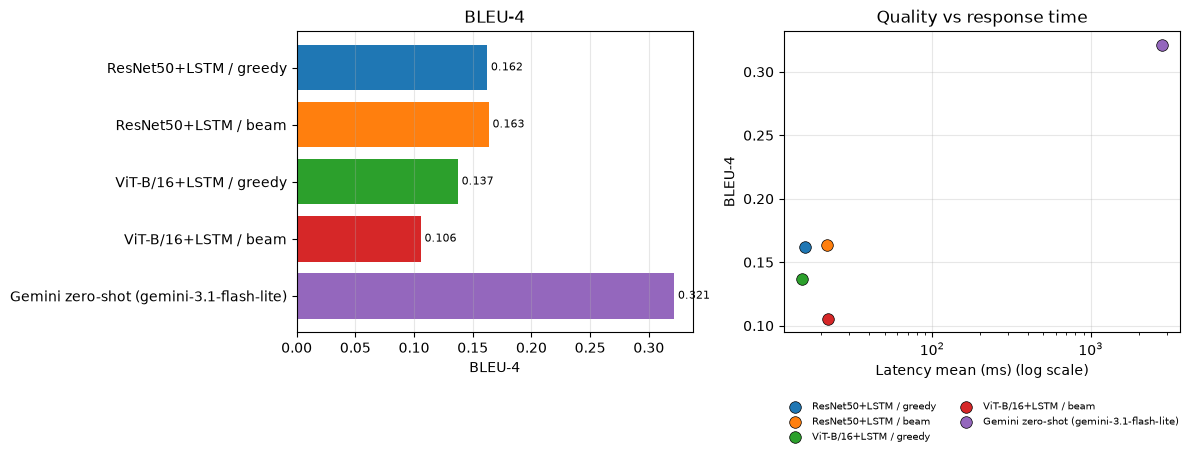

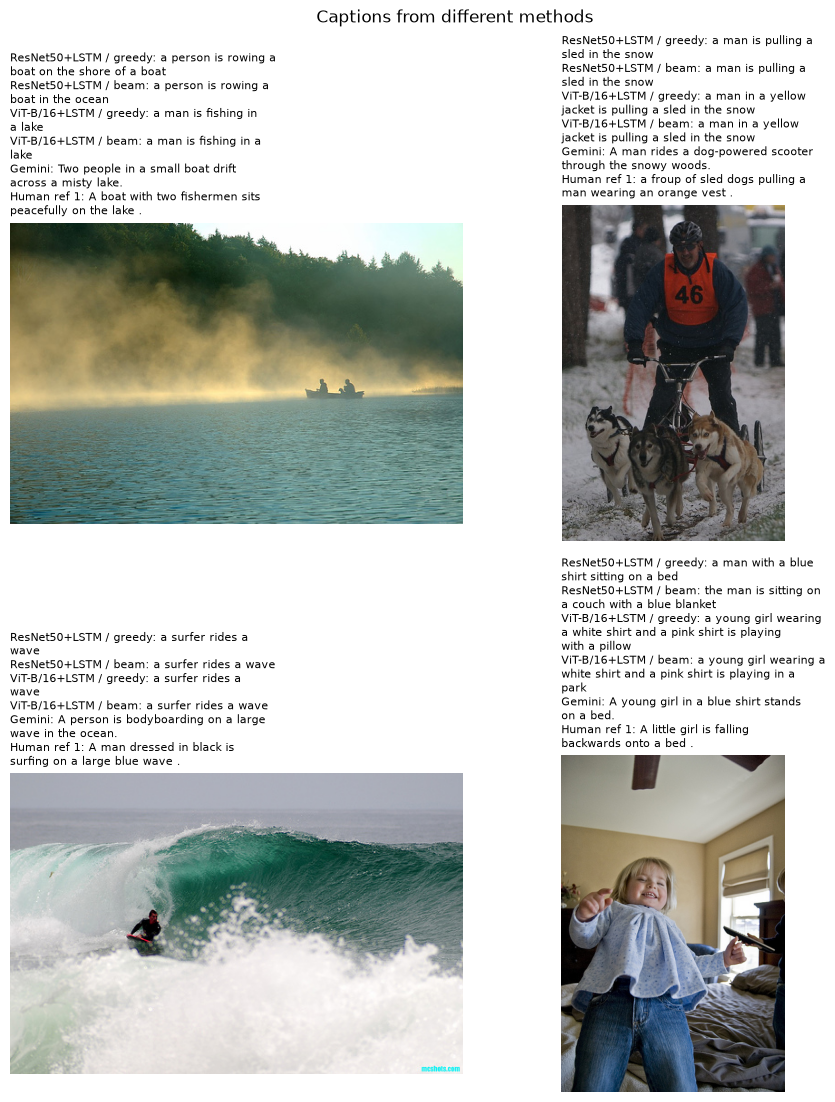

In [23]:
plot_method_comparison(cmp, "BLEU-4", "Latency mean (ms)", RESULT / "comparison_bleu4.png")
if "BERTScore-F1" in cmp.columns:
    plot_method_comparison(cmp, "BERTScore-F1", "Latency mean (ms)", RESULT / "comparison_bertscore.png")

# 同一批影像上，各方法的描述並排比較
gem_by_pos = dict(zip(gem_idx, gem_cap_df["caption"]))
rows = []
for i in gem_idx[:4]:
    lines = [(n, all_caps[n][i]) for n in methods] + [("Gemini", gem_by_pos[i]), ("Human ref 1", test_refs[i][0])]
    rows.append({"image": test_records[i]["image"], "lines": lines})
plot_caption_examples(images_dir, rows, ncols=2, title="Captions from different methods", save_path=RESULT / "comparison_samples.png")

with open(RESULT / "all_test_captions.json", "w", encoding="utf-8") as f:
    json.dump({"images": [r["image"] for r in test_records], **all_caps}, f, ensure_ascii=False, indent=1)

### 實驗結果與分析

一、解碼方式(Greedy vs. Beam)  
ResNet50 上 Beam(0.163)與 Greedy(0.162)幾乎無差，ViT 上 Beam(0.106)反而低於 Greedy(0.137)，顯示 Beam Search 不一定更好，且需付出額外運算時間

二、編碼器(ResNet50 vs. ViT)  
在凍結編碼器、相同 LSTM 解碼器的條件下，ResNet50 的 BLEU-4 優於 ViT，推測是 ViT 的 CLS 全域特徵較偏向分類、缺少描述所需的細節

三、自行訓練模型 vs. Gemini  
Gemini zero-shot 的 BLEU-4(0.321)約為最佳本地模型的 2 倍，但延遲約 10 秒，比本地的約 20 ms 慢 2~3 個數量級，呈現品質與速度的取捨